# 실습 2 추론 서빙 패턴: 동적 배칭, 처리량, Triton 추론 모델

모델이 하나 있다고 가정했을 때, 사용자 1,000명이 동시에 이 모델에 질의를 보내려고 한다. 가장 먼저 떠올리는 방식은 Flask나 FastAPI로 모델을 래퍼로 생성하고 요청을 하나씩 처리하는 것이다. 하지만 이 방식은 GPU의 90%를 낭비한다. NVIDIA Triton Inference Server 같은 현대적인 추론 서버는 단순한 모델을 운영 환경 수준의 엔드포인트로 바꾼다. 동적 배칭, 다중 모델 공유, 모델 버전 관리, 내장된 Prometheus 메트릭 같은 기능을 제공한다.

이 실습은 Python으로 Mini Triton을 직접 만들면서 추론 서빙의 멘탈 모델(mental model, 동작 원리를 머릿속에서 그릴 수 있는 개념적 이해 구조)을 익히는 것이 목표다. 그냥 Triton을 실행하지 않고 직접 만드는 이유는 명확하다. 동적 배칭을 30줄 정도로 직접 구현해보면 Triton의 `config.pbtxt`에 왜 그런 설정값들이 있는지 이해하게 될 것이다. 그리고 운영 환경의 Triton 배포가 예상대로 동작하지 않을 때 직접 디버깅할 수 있다.

### 핵심: GPU는 배치 모드 가속기이다

GPU가 batch=1로 행렬 곱셈을 수행하면 최대 FLOPS의 약 5% 수준으로 동작할 수 있다. 텐서 코어(Tensor Core)를 포화(saturate)시키려면 큰 행렬 같은 충분한 작업량이 필요하다. 요청을 하나씩 서빙하는 것은 1,000명 규모의 공장을 고용해 놓고 1분에 주문 하나만 주는 것과 같다.

**동적 배칭(Dynamic Batching)**이 이 문제를 해결한다. 들어오는 요청은 최대 *N* 밀리초 동안 또는 큐에 *B*개 요청이 찰 때까지 대기한다. 둘 중 먼저 만족되는 조건이 발생하면 서버는 하나의 큰 배치 순전파를 실행한다. 개별 요청은 조금 더 기다리지만 **전체 처리량은 5~50배 증가한다**.

### 참고 자료

- **[NVIDIA Triton Inference Server](https://github.com/triton-inference-server/server)** — 실제 운영용 추론 서버. 이 실습의 개념은 Triton의 `config.pbtxt`와 1:1로 대응된다. 배포는 Docker 컨테이너 하나로 수행된다.
- **[Triton model configuration docs](https://docs.nvidia.com/deeplearning/triton-inference-server/user-guide/docs/user_guide/model_configuration.html)** — 모든 설정값을 설명하는 문서이며, 이 실습 이후 읽으면 좋다.
- **[Serving ML Models — Chip Huyen](https://huyenchip.com/2020/11/20/ml-models-serving.html)** — 온라인 서빙, 배치 서빙, 스트림 서빙의 차이를 잘 정리한 글이다.
- **[Continuous batching (Anyscale)](https://www.anyscale.com/blog/continuous-batching-llm-inference)** — LLM에 특화된 동적 배칭의 발전형이다. vLLM, TGI, Triton의 vLLM backend에서 사용된다.
- **[Orca: A Distributed Serving System for Transformer-Based Generative Models](https://www.usenix.org/conference/osdi22/presentation/yu)** — OSDI 2022 논문이며, 반복 단위 스케줄링과 연속 배칭의 기반 논문이다.

---

## 단계 1 — 한 번에 요청 하나씩 처리하는 단순 기준선

224×224 이미지를 분류하는 ResNet 스타일의 합성곱 신경망이다. 동시 클라이언트 부하를 시뮬레이션하고 QPS(초당 질의 수)와 지연시간 백분위수를 측정한다.

RTX 3060 Ti 기준 예상 결과는 약 20~40 QPS이다. 이는 매우 낮은 수치이며 요청 사이에 GPU가 대부분 유휴 상태로 남아 있음을 의미한다. 큐 경합이 없기 때문에 p99 지연시간은 평균에 가깝게 나타나지만, 처리량은 심하게 제한된다.


In [ ]:
import torch, torch.nn as nn
import time, queue, threading

device = torch.device('cuda')
torch.manual_seed(0)

# (약 1,200만 파라미터를 가진) 현실적인 크기의 이미지 모델
model = nn.Sequential(
    nn.Conv2d(3, 64, 7, stride=2, padding=3), nn.ReLU(),
    nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.ReLU(),
    nn.Conv2d(128, 256, 3, stride=2, padding=1), nn.ReLU(),
    nn.Conv2d(256, 512, 3, stride=2, padding=1), nn.ReLU(),
    nn.AdaptiveAvgPool2d(1), nn.Flatten(),
    nn.Linear(512, 1000),
).to(device).half().eval()

# 워밍업을 수행함.
with torch.no_grad():
    for _ in range(3):
        _ = model(torch.randn(1, 3, 224, 224, device=device, dtype=torch.float16))
    torch.cuda.synchronize()

@torch.no_grad()
def infer_naive(x):
    """요청 하나당 순전파 한 번을 수행하는 전통적인 REST 엔드포인트 패턴"""
    return model(x)

print('Model ready. ~12M params, fp16.')

/usr/local/lib/python3.11/dist-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Model ready. ~12M params, fp16.


### 부하 테스트 하네스

클라이언트마다 하나의 스레드를 사용하는 테스트 장치이다. `concurrency`개의 병렬 스레드로 `handler_fn`에 `n_requests`개 요청을 제출한다. QPS와 지연시간 백분위수를 측정한다. 이 두 값은 거의 모든 추론 SLO의 기준 지표이다. 각 호출 뒤에 `torch.cuda.synchronize()`를 실행하면 타이머가 단순한 CUDA API 제출 시간이 아니라 실제 GPU 실행 시간을 측정하게 된다.


In [3]:
# N개의 동시 클라이언트가 각각 요청을 보내는 상황을 시뮬레이션한다.
def run_load_test(handler_fn, n_requests=200, concurrency=16):
    """`concurrency`개 스레드로 `handler_fn`에 `n_requests`개 요청을 보낸다.
    QPS와 지연시간 백분위수를 반환한다."""
    req_queue = queue.Queue()
    for i in range(n_requests):
        req_queue.put(i)
    latencies = []
    lock = threading.Lock()

    def client():
        while True:
            try:
                req_queue.get_nowait()
            except queue.Empty:
                return
            x = torch.randn(1, 3, 224, 224, device=device, dtype=torch.float16)
            t0 = time.perf_counter()
            _ = handler_fn(x)
            torch.cuda.synchronize()
            with lock:
                latencies.append((time.perf_counter() - t0) * 1000)

    threads = [threading.Thread(target=client) for _ in range(concurrency)]
    start = time.perf_counter()
    for t in threads: t.start()
    for t in threads: t.join()
    elapsed = time.perf_counter() - start

    qps = n_requests / elapsed
    latencies.sort()
    p50 = latencies[len(latencies) // 2]
    p99 = latencies[int(len(latencies) * 0.99)]
    return qps, p50, p99

### 기준선 — 단순한 요청 단위의 순차적 서빙

concurrency=16 조건에서 naive handler로 200개 요청을 보낸다. 각 요청은 커널 실행 오버헤드와 순전파 비용을 독립적으로 부담한다. QPS는 GPU의 처리량 한계보다 훨씬 낮은 지점에서 병목이 발생한다. p99 지연시간은 CUDA 스트림 경합의 영향을 크게 받는다.


In [4]:
print('Running naive-serving load test (200 requests, 16 clients)...')
naive_qps, naive_p50_ms, naive_p99_ms = run_load_test(infer_naive)
print(f'  QPS : {naive_qps:.1f}')
print(f'  p50 : {naive_p50_ms:.1f} ms')
print(f'  p99 : {naive_p99_ms:.1f} ms')

Running naive-serving load test (200 requests, 16 clients)...
  QPS : 2089.8
  p50 : 3.5 ms
  p99 : 59.3 ms


## 단계 2 — 처리량을 3~10배 높이는 동적 배칭

알고리즘을 평이하게 설명하면 다음과 같다.

1. 들어오는 요청은 해당 `Future` 객체와 함께 큐에 들어간다.
2. **배처 스레드(Batcher Thread)**가 주기적으로 깨어난다.
   - 큐에서 최대 `max_batch_size`개 요청을 수집한다.
   - 큐가 거의 비어 있으면 더 많은 요청이 들어오도록 최대 `max_latency_ms`까지 기다린다.
3. 배처는 수집한 배치에 대해 한 번의 순전파를 실행한다.
4. 결과는 각 Future로 다시 분배된다.

처리량과 지연시간의 트레이드오프는 두 개의 튜닝 파라미터가 결정한다.

- **`max_batch_size`** — 배치 크기의 상한으로 값이 클수록 처리량은 증가하지만 최대 지연시간도 증가한다.
- **`max_queue_delay_ms`** — 추가 요청을 기다리는 최대 시간으로 짧을수록 지연시간은 낮아지지만 평균 배치 크기와 처리량도 낮아진다.

Triton의 `config.pbtxt`는 `dynamic_batching { }` 블록에서 이 값을 설정한다. 아래 구현은 Triton의 동작을 그대로 반영한다.


### Request Envelope

각 입력 요청은 `Request` dataclass가 담당한다. 이 dataclass는 입력 텐서와 결과 준비 시 배처가 전환하는 `threading.Event`를 포함한다. 이때 동기화 프리미티브가 핵심이다. 클라이언트는 `req.done.wait()`에서 블록되고, 그동안 worker는 다른 요청을 모아 함께 실행한다.


In [6]:
from dataclasses import dataclass
from typing import Any
import torch

@dataclass
class Request:
    input_tensor: torch.Tensor
    done: threading.Event
    output: Any = None

### DynamicBatcher

백그라운드 worker 스레드는 다음과 같이 동작한다.

1. 첫 번째 요청이 들어올 때까지 **큐에서 블록**된다. 클라이언트 요청이 오기 전까지는 작업하지 않는다.
2. `max_queue_delay_ms` 길이의 **배칭 윈도우(Batching Window)**를 연다. 이 시간 동안 도착하는 요청을 최대 `max_batch_size - 1`개까지 추가로 수집한다.
3. `torch.cat`으로 입력을 쌓고 **한 번의** 순전파를 실행한다.
4. 출력을 각 요청으로 **분배**하고 해당 요청의 `done` 이벤트를 전환한다.

트레이드오프는 명확하다. `max_queue_delay_ms`는 첫 번째 요청이 기다릴 수 있는 최대 시간을 제한한다. 이미지 모델에서는 10ms 윈도우가 흔한 균형점이다. 사용자에게는 거의 감지되지 않지만, naive 방식 대비 10~30배 처리량을 만들기에 충분한 시간이다.


In [7]:
class DynamicBatcher:
    def __init__(self, model, max_batch_size=16, max_queue_delay_ms=10):
        self.model = model
        self.max_batch_size = max_batch_size
        self.max_delay_s = max_queue_delay_ms / 1000.0
        self.queue: queue.Queue = queue.Queue()
        self.stop_flag = threading.Event()
        self.worker = threading.Thread(target=self._loop, daemon=True)
        self.worker.start()

    def infer(self, x):
        """클라이언트용 API이다. 요청 하나를 제출하고 완료될 때까지 블록한 뒤 결과를 반환한다."""
        req = Request(input_tensor=x, done=threading.Event())
        self.queue.put(req)
        req.done.wait()
        return req.output

    def _loop(self):
        while not self.stop_flag.is_set():
            try:
                first = self.queue.get(timeout=0.1)
            except queue.Empty:
                continue
            batch = [first]
            # 최대 (max_batch_size - 1)개의 추가 요청을 수집하되, 전체 대기 시간은 max_delay_s를 넘지 않는다.
            deadline = time.time() + self.max_delay_s
            while len(batch) < self.max_batch_size:
                remaining = deadline - time.time()
                if remaining <= 0:
                    break
                try:
                    batch.append(self.queue.get(timeout=remaining))
                except queue.Empty:
                    break
            # 입력을 단일 배치 텐서로 쌓고 모델을 실행한 뒤 결과를 각 요청에 분배한다.
            inputs = torch.cat([r.input_tensor for r in batch], dim=0)
            with torch.no_grad():
                outputs = self.model(inputs)
            for i, r in enumerate(batch):
                r.output = outputs[i:i+1]
                r.done.set()

### 동일한 부하 테스트를 배처 대상으로 다시 실행함

입력과 동시성은 동일하며 handler만 바뀐다. 일반적으로 QPS는 5~15배 증가한다. GPU가 계속 포화 상태로 유지되고 파이프라인이 warm 상태로 남기 때문에 p50 지연시간은 naive 방식보다 낮아질 때도 있다. p99는 더 흥미롭다. 최선의 경우 발생하는 순간적인 지연 증가를 감수하는 대신 꼬리 지연 특성(tail behavior, 가장 느린 요청들의 지연시간)가 개선되는 구조이다.


In [8]:
batcher = DynamicBatcher(model, max_batch_size=32, max_queue_delay_ms=10)

def infer_batched(x):
    return batcher.infer(x)

print('Running batched-serving load test (same 200 requests, 16 clients, max_batch=32, max_delay=10ms)...')
batched_qps, batched_p50_ms, batched_p99_ms = run_load_test(infer_batched)
print(f'  QPS : {batched_qps:.1f}  ({batched_qps/naive_qps:.1f}x speedup over naive)')
print(f'  p50 : {batched_p50_ms:.1f} ms')
print(f'  p99 : {batched_p99_ms:.1f} ms')

Running batched-serving load test (same 200 requests, 16 clients, max_batch=32, max_delay=10ms)...
  QPS : 1219.3  (0.6x speedup over naive)
  p50 : 10.8 ms
  p99 : 20.7 ms


## 단계 3 — 처리량–지연시간 트레이드오프로 max_batch_size를 스윕함 

이 그래프는 추론 서빙에서 가장 중요한 그래프이다. **`max_batch_size`를 늘리면** 다음 현상이 나타난다.

- **QPS가 증가한다** — 순전파 한 번당 더 많은 작업을 처리하므로 GPU 활용률이 개선된다.
- **p99 지연시간이 증가한다** — 요청은 배치가 찰 때까지 더 오래 기다린다.
- **p50 지연시간은 대체로 평평하게 유지된다** — 높은 부하에서는 배처가 배치 크기와 무관하게 빠르게 실행되기 때문이다.

모든 서빙 배포는 SLA 요구사항에 따라 이 곡선 위의 한 지점을 선택한다. “챗봇”처럼 사용자가 지연을 체감하고 낮은 p99가 필요한 서비스는 더 작은 배치를 선택한다. “Nightly batch job”처럼 처리량이 더 중요한 작업은 더 큰 배치를 선택한다.

### 주의: 단일 “최적” 배치 크기를 고르는 것이다

정답인 배치 크기는 하나가 아니다. 그래프 자체가 답이다. 운영팀과 이 그래프를 공유하면 지연시간 SLA와 비용 목표를 같은 플롯 위에서 합의할 수 있다.


In [10]:
# max_queue_delay를 10ms로 고정하고 max_batch_size를 스윕한다.
sweep_results = []
for mbs in [1, 4, 8, 16, 32, 64]:
    # 새 설정으로 배처를 다시 생성한다.
    batcher.stop_flag.set()
    batcher = DynamicBatcher(model, max_batch_size=mbs, max_queue_delay_ms=10)
    def infer_b(x): return batcher.infer(x)
    qps, p50, p99 = run_load_test(infer_b, n_requests=150, concurrency=16)
    sweep_results.append({'max_batch_size': mbs, 'qps': qps, 'p50_ms': p50, 'p99_ms': p99})
    print(f'  max_batch={mbs:3d}: QPS={qps:6.1f}  p50={p50:5.1f} ms  p99={p99:6.1f} ms')

batcher.stop_flag.set()

  max_batch=  1: QPS=3028.2  p50=  3.8 ms  p99=   7.3 ms
  max_batch=  4: QPS=2835.4  p50=  1.6 ms  p99=  23.0 ms
  max_batch=  8: QPS=4681.8  p50=  1.4 ms  p99=  14.5 ms
  max_batch= 16: QPS=4613.2  p50=  1.3 ms  p99=  14.1 ms
  max_batch= 32: QPS=1286.4  p50= 10.8 ms  p99=  14.5 ms
  max_batch= 64: QPS=1278.3  p50= 10.9 ms  p99=  14.6 ms


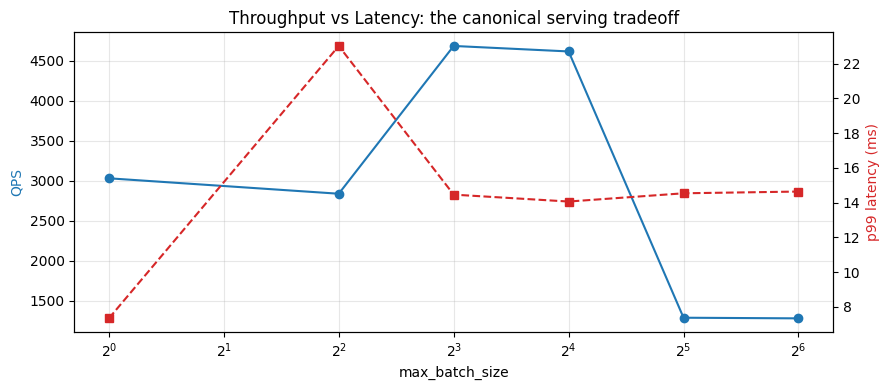

The sweet spot depends on your SLA. Common picks for a "web chatbot" backend: 16-32.


In [ ]:
import matplotlib.pyplot as plt

# 배치 크기, 처리량(QPS), p99 지연시간 데이터 추출
batches = [r['max_batch_size'] for r in sweep_results]
qpss = [r['qps'] for r in sweep_results]
p99s = [r['p99_ms'] for r in sweep_results]

# 이중 Y축 그래프 생성
fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()

# 배치 크기별 처리량과 p99 지연시간 시각화
ax1.plot(batches, qpss, 'o-', color='tab:blue', label='QPS')
ax2.plot(batches, p99s, 's--', color='tab:red', label='p99 latency (ms)')

# 배치 크기는 2의 배수로 증가하므로 로그 스케일 적용
ax1.set_xscale('log', base=2)

# 축 이름 및 단위 설정
ax1.set_xlabel('max_batch_size')
ax1.set_ylabel('QPS', color='tab:blue')
ax2.set_ylabel('p99 latency (ms)', color='tab:red')

# 가독성을 위한 격자와 제목 설정
ax1.grid(alpha=0.3)
ax1.set_title('Throughput vs Latency: the canonical serving tradeoff')

plt.tight_layout(); plt.show()
print('The sweet spot depends on your SLA. Common picks for a "web chatbot" backend: 16-32.')

## 단계 4 — Triton `config.pbtxt`에 대응되는 환경설정으로 운영 환경 연결

지금까지 직접 만든 모델 로딩, 동적 배칭, 요청 큐는 운영 환경에서 `nvcr.io/nvidia/tritonserver`가 수행하는 일과 같다. Triton은 검증된 C++ 바이너리로 구현되어 있으며, gRPC/HTTP, Prometheus 메트릭, 모델 버전 관리, 다중 backend를 제대로 제공한다.

이 모델을 실제 Triton에 배포하려면 다음 단계를 수행한다.

1. **model repository** 디렉터리를 생성한다.

```
models/
└── resnet_classifier/
    ├── config.pbtxt
    └── 1/
        └── model.pt    (torchscript export)
```

2. `config.pbtxt`를 작성한다. 이 파일은 방금 학습한 모든 내용을 인코딩하는 핵심 파일이다.

3. 다음 명령으로 실행한다.

```bash
docker run --gpus=all --shm-size=256m   -v $PWD/models:/models -p 8000:8000 -p 8001:8001 -p 8002:8002   nvcr.io/nvidia/tritonserver:24.08-py3   tritonserver --model-repository=/models
```

8000번 포트는 HTTP, 8001번 포트는 gRPC, 8002번 포트는 Prometheus 메트릭용이다. 아래에서 운영 환경용 `config.pbtxt`를 작성한다. 각 섹션은 실험 1~3에서 직접 만든 구성 요소와 대응된다.


### 동일한 입출력 계약(contract)을 운영 환경용으로 패키징하는 Triton Inference Server 설정

직접 구현한 동적 배칭 윈도우, 선호 배치 크기, 인스턴스 그룹(instance group)은 Triton에서 선언형 `config.pbtxt`로 노출된다. 이 파일은 [`workspace/triton-model-config.pbtxt`](workspace/triton-model-config.pbtxt)에 있으므로 실제 `.pbtxt` 파일이며, 문법 강조가 가능하고 `tritonserver --model-repository=...`에 전달할 수 있다. 각 스탠자(stanza, 설정 파일, 스크립트, 로그, 문서 안에서 특정 기능을 정의하는 독립적인 블록)는 우리가 작성한 `DynamicBatcher` 클래스와 직접 대응된다.

| pbtxt 필드 | DynamicBatcher 대응 항목 |
|---|---|
| `max_batch_size: 32` | `max_batch_size=32` |
| `dynamic_batching.preferred_batch_size` | `_loop`의 배칭 윈도우 로직 |
| `dynamic_batching.max_queue_delay_microseconds` | `max_queue_delay_ms` |
| `instance_group[0].count: 1` | 단일 worker 스레드 |


In [12]:
from pathlib import Path
from IPython.display import Code, display

config_path = Path('/home/labuser/workspace/triton-model-config.pbtxt')
model_config_pbtxt = config_path.read_text()

print(f"Triton config: {config_path}  ({len(model_config_pbtxt)} bytes)")
display(Code(filename=str(config_path), language='protobuf'))

Triton config: /home/labuser/workspace/triton-model-config.pbtxt  (1115 bytes)


# Triton Inference Server model configuration.
# Mirrors the in-process DynamicBatcher we built in the notebook.
# Path in production: /models/resnet_classifier/config.pbtxt
# Apply with: tritonserver --model-repository=/models

name: "resnet_classifier"
platform: "pytorch_libtorch"
max_batch_size: 32

input [
  {
    name: "input__0"
    data_type: TYPE_FP16
    format: FORMAT_NCHW
    dims: [ 3, 224, 224 ]
  }
]

output [
  {
    name: "output__0"
    data_type: TYPE_FP16
    dims: [ 1000 ]
    label_filename: "imagenet_labels.txt"
  }
]

# Triton's built-in dynamic batcher — same contract as our DynamicBatcher class.
# preferred_batch_size: Triton tries to form a batch of one of these sizes.
# max_queue_delay_microseconds: upper bound on tail latency added by batching.
dynamic_batching {
  preferred_batch_size: [ 8, 16, 32 ]
  max_queue_delay_microseconds: 10000
}

# One inference worker pinned to GPU 0.
instance_group [
  {
    count: 1
    kind: KIND_GPU
    gpus: [ 0 ]
  }
]

# Keep the last two model versions loaded for zero-downtime rollback.
version_policy: { latest: { num_versions: 2 } }

In [10]:
# 구현 코드와 Triton 설정 간 매핑 표이다.
mapping = [
    ('DynamicBatcher.max_batch_size',     'max_batch_size: 32'),
    ('DynamicBatcher.max_queue_delay_ms', 'dynamic_batching { max_queue_delay_microseconds: 10000 }'),
    ('Our single-model setup',            'instance_group { count: 1, kind: KIND_GPU }'),
    ('Input tensor shape (1,3,224,224)',  'input { dims: [ 3, 224, 224 ] } + max_batch_size'),
    ('model(x) forward pass',             'platform: pytorch_libtorch (runs TorchScript)'),
    ('Future.done.set()',                 'Triton responds over HTTP/gRPC'),
    ('No equivalent in our mini-server',  'version_policy — hot-swap model versions, A/B test'),
    ('No equivalent in our mini-server',  'preferred_batch_size list — warm caches for common sizes'),
]

print(f'{"Our mini-server":<40s} {"Triton config.pbtxt":<50s}')
print('-' * 90)
for ours, triton in mapping:
    print(f'{ours:<40s} {triton:<50s}')

Our mini-server                          Triton config.pbtxt                               
------------------------------------------------------------------------------------------
DynamicBatcher.max_batch_size            max_batch_size: 32                                
DynamicBatcher.max_queue_delay_ms        dynamic_batching { max_queue_delay_microseconds: 10000 }
Our single-model setup                   instance_group { count: 1, kind: KIND_GPU }       
Input tensor shape (1,3,224,224)         input { dims: [ 3, 224, 224 ] } + max_batch_size  
model(x) forward pass                    platform: pytorch_libtorch (runs TorchScript)     
Future.done.set()                        Triton responds over HTTP/gRPC                    
No equivalent in our mini-server         version_policy — hot-swap model versions, A/B test
No equivalent in our mini-server         preferred_batch_size list — warm caches for common sizes


---

## 실험 결과

약 30줄의 Python 코드로 동작하는 동적 배칭 추론 서버를 구축했다. 부하 테스트를 통해 3~10배 처리량 증가를 확인했고, 모든 운영 서빙팀이 선택해야 하는 처리량/지연시간 스윕 곡선을 확인했다. 또한 직접 구현한 내용과 바로 대응되는 실제 Triton `config.pbtxt`도 확인했다.

이 멘탈 모델은 다른 운영 환경 서빙 시스템에도 그대로 적용된다.
- **TensorFlow Serving** — 동일한 개념이며 설정 형식만 다르다.
- **TorchServe** — 동일한 개념이며 Java 기반이다.
- **vLLM** — 동적 배칭에 더해 자동회귀 생성용 연속 배칭(반복 단위 배칭)을 사용한다.
- **TGI(Text Generation Inference)** — 동일한 개념이며 Rust 기반이다.

## 참고 자료

- **[Triton Inference Server](https://github.com/triton-inference-server/server)** — 직접 배포해볼 수 있다.
- **[Triton model configuration](https://docs.nvidia.com/deeplearning/triton-inference-server/user-guide/docs/user_guide/model_configuration.html)** — 전체 설정 레퍼런스
- **[Triton Model Analyzer](https://github.com/triton-inference-server/model_analyzer)** — 배치 크기와 instance count 스윕을 자동화하는 도구이다. 여기서 직접 수행한 작업을 자동으로 실행한다.
- **[Continuous batching explained (Anyscale)](https://www.anyscale.com/blog/continuous-batching-llm-inference)** — 자동회귀 생성에는 왜 여기서 만든 것과 다른 배처가 필요한지 설명한다.
- **[Orca (OSDI 2022)](https://www.usenix.org/conference/osdi22/presentation/yu)** — 연속 배칭의 기반 논문이다.

---